<a href="https://colab.research.google.com/github/sbajnaid/Lab-3/blob/main/ML_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set()

In [4]:
#load dataset
df = pd.read_csv("/content/[Lab 2] Pass-Fail Data.csv")

In [5]:
df.head()

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
0,1,95,92,88,12,1
1,2,88,85,79,10,1
2,3,60,55,58,4,0
3,4,72,70,65,6,1
4,5,40,45,50,3,0


The dataset consists of student records, where each row displays the student's information throughout an academic term. The columns include student id, attendance percentage, homework percentage, midterm score, study hours per week, and pass. We can observe that all the rows contain purely numerical data, and the 'pass' column so far consists of binary values.

In [6]:
#checking data type
df.dtypes

,0
student_id,int64
attendance_pct,int64
homework_pct,int64
midterm_score,int64
study_hours_per_week,int64
pass,int64


All the columns are stored as integer types of 64 bits. This is accurate and correct for the expected values.

In [7]:
#checking missing values
print(df.isna().sum())

student_id              0
attendance_pct          0
homework_pct            0
midterm_score           0
study_hours_per_week    0
pass                    0
dtype: int64


The sum of missing values is 0 in all the columns, therefore we can say that there are no missing values. If we used df.isna(), all the rows would show 'False'.

In [8]:
#checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


From the result, we can see that there are no duplicate rows.

In [9]:
#checking duplicate columns
df.columns.duplicated().any()

np.False_

No duplicate columns.

In [10]:
#finding number of rows and columns
print("Shape", df.shape)

Shape (100, 6)


The dataset consists of 100 rows and 6 columns.

In [11]:
#descriptive summary
df.describe(include='all')

,student_id,attendance_pct,homework_pct,midterm_score,study_hours_per_week,pass
count,100.000000,100.000000,100.00000,100.000000,100.00000,100.000000
mean,50.500000,69.520000,69.03000,68.780000,7.28000,0.600000
std,29.011492,17.651783,17.01304,14.717254,3.62115,0.492366
min,1.000000,30.000000,35.00000,42.000000,2.00000,0.000000
25%,25.750000,55.000000,55.00000,56.000000,4.00000,0.000000
50%,50.500000,72.500000,70.00000,68.000000,7.00000,1.000000
75%,75.250000,85.000000,85.00000,82.000000,10.00000,1.000000
max,100.000000,95.000000,96.00000,97.000000,15.00000,1.000000


Here is a summary of the data in the dataset. We can see average, upper bound, and lower bound values, as well as the maximum and minimum for each attribute.

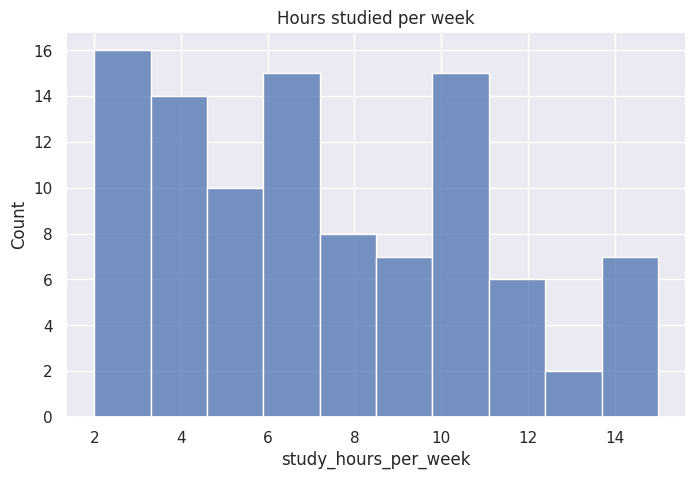

In [13]:
#univariate analysis: histogram of hours studied
plt.figure(figsize=(8,5))
sns.histplot(df['study_hours_per_week'], bins=10)
plt.title("Hours studied per week")
plt.show()

This histogram can be called loosely right skewed (or right skewed with a few exceptions). Most students study few hours per week, and the number of students decreases as the study hours increase, however there are a lot of students who study 6-7 and 10-11 hours per week.

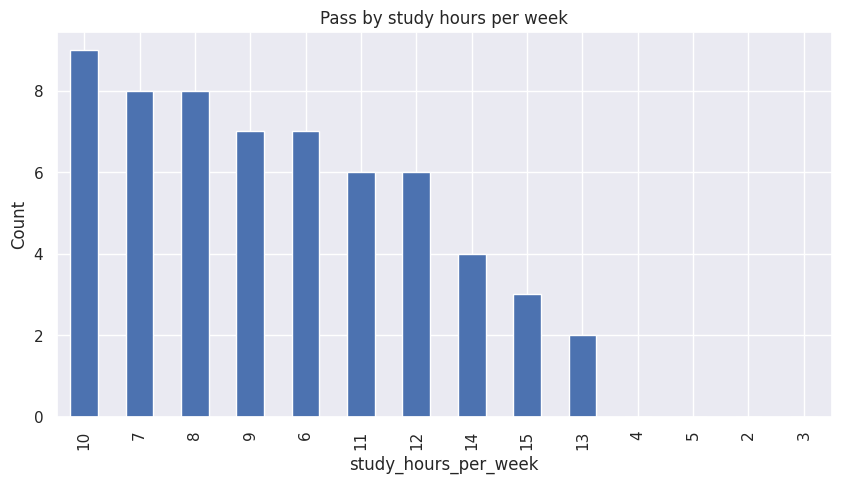

,pass
study_hours_per_week,
10,9
7,8
8,8
9,7
6,7
11,6
12,6
14,4
15,3


In [20]:
#bivariate analysis: bar graph showing pass count by number of hours studied per week

passbyhours = df.groupby('study_hours_per_week')['pass'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
passbyhours.plot(kind='bar')
plt.title("Pass by study hours per week")
plt.ylabel("Count")
plt.show()

passbyhours

This bar chart displays the amount of students that passed and the number of hours they studied per week. As we can see, the students who studied 5 hours or less did not pass.

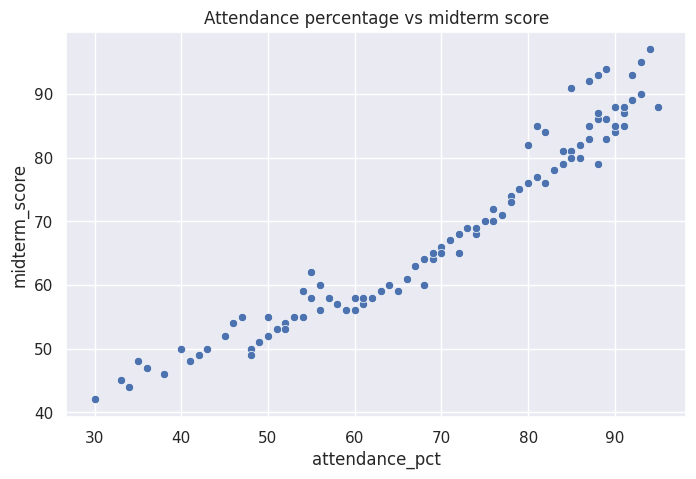

In [22]:
#bivariate analysis: scatterplot showing studens' attendance and their midterm scores
plt.figure(figsize=(8,5))
sns.scatterplot(x='attendance_pct', y='midterm_score', data=df)
plt.title("Attendance percentage vs midterm score")
plt.show()

This scatterplot shows a strong positive correlation between attendance percentage and students' midterm scores. As the attendance increases, the midterm score increases.

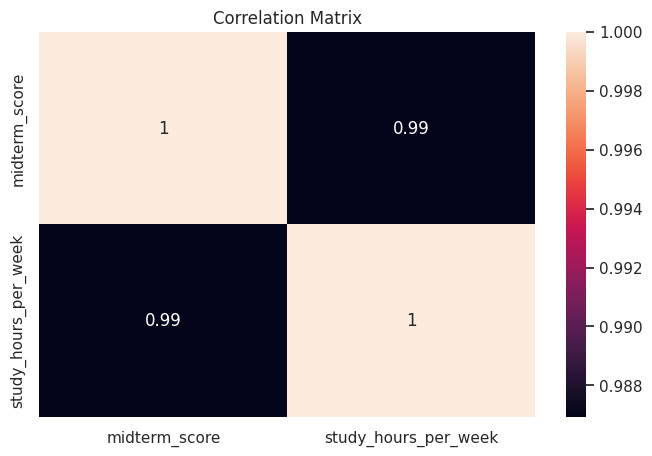

In [25]:
#bivariate analysis: correlation matrix showing the correlation between midterm scores and the amount of hours studied per week
plt.figure(figsize=(8,5))
sns.heatmap(df[['midterm_score', 'study_hours_per_week']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows a strong positive correlation between midterm scores and the amount of hours studied per week. All the values are either 1 or very close to 1, which is an indicator of strong correlation. This suggests that midterm scores are directly affected by the amount of time spent studying.